In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from collections import defaultdict
import matplotlib.pyplot as plt


In [18]:
df = pd.read_csv(r"C:\Users\zhaoz\OneDrive\Desktop\mushrooms.csv")
df = df.drop('veil-type', axis=1)

In [19]:
encoders = {}
for col in df.columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

In [20]:
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,2,7,7,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,2,7,7,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,2,7,7,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,2,7,7,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,2,7,7,2,1,0,3,0,1


In [21]:
X = df.drop('class', axis=1)
y = df['class']
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

In [22]:
class NaiveBayes:
    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def fit(self, X, y):
        self.classes = np.unique(y)
        n_samples, n_features = X.shape

        # Prior P(y)
        self.class_probs = {}
        for c in self.classes:
            self.class_probs[c] = np.sum(y == c) / n_samples

        # Likelihood P(x_i | y)
        self.feature_probs = {
            c: [defaultdict(float) for _ in range(n_features)]
            for c in self.classes
        }

        for c in self.classes:
            X_c = X[y == c]

            for i in range(n_features):
                values = X.iloc[:, i].unique()
                total = len(X_c)

                for v in values:
                    count = np.sum(X_c.iloc[:, i] == v)

                    # Laplace smoothing
                    prob = (count + self.alpha) / (total + self.alpha * len(values))
                    self.feature_probs[c][i][v] = prob

    def predict(self, X):
        preds = []

        for _, row in X.iterrows():
            class_scores = {}

            for c in self.classes:
                log_prob = np.log(self.class_probs[c])

                for i, val in enumerate(row):
                    prob = self.feature_probs[c][i].get(val, 1e-9)
                    log_prob += np.log(prob)

                class_scores[c] = log_prob

            preds.append(max(class_scores, key=class_scores.get))

        return np.array(preds)

    def predict_proba(self, X):
        probs = []

        for _, row in X.iterrows():
            class_scores = {}

            for c in self.classes:
                log_prob = np.log(self.class_probs[c])

                for i, val in enumerate(row):
                    prob = self.feature_probs[c][i].get(val, 1e-9)
                    log_prob += np.log(prob)

                class_scores[c] = log_prob

            # Convert log → probability (stable softmax)
            max_log = max(class_scores.values())
            exp_scores = {c: np.exp(v - max_log) for c, v in class_scores.items()}
            total = sum(exp_scores.values())

            probs.append([exp_scores[c] / total for c in self.classes])

        return np.array(probs)

In [23]:
alphas = [0.01, 0.1, 0.5, 1, 2, 5]

train_accs = []
val_accs = []

for a in alphas:
    model = NaiveBayes(alpha=a)
    model.fit(X_train, y_train)

    # Train accuracy
    y_train_pred = model.predict(X_train)
    train_acc = np.mean(y_train_pred == y_train)

    # Validation accuracy
    y_val_pred = model.predict(X_val)
    val_acc = np.mean(y_val_pred == y_val)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"alpha={a}, train={train_acc:.4f}, val={val_acc:.4f}")

alpha=0.01, train=0.9902, val=0.9877
alpha=0.1, train=0.9803, val=0.9760
alpha=0.5, train=0.9620, val=0.9600
alpha=1, train=0.9561, val=0.9508
alpha=2, train=0.9460, val=0.9440
alpha=5, train=0.9380, val=0.9372


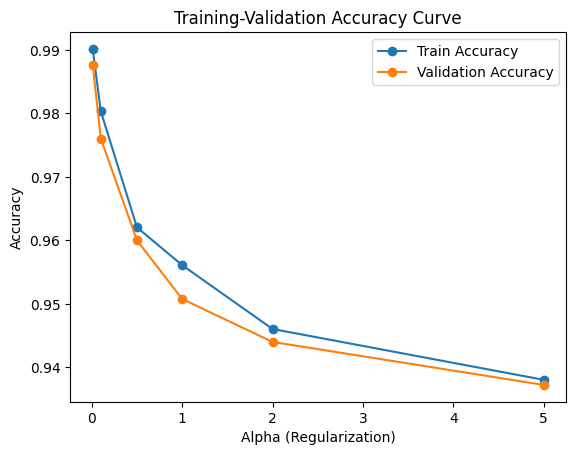

In [27]:
plt.plot(alphas, train_accs, marker='o', label='Train Accuracy')
plt.plot(alphas, val_accs, marker='o', label='Validation Accuracy')

plt.xlabel('Alpha (Regularization)')
plt.ylabel('Accuracy')
plt.title('Training-Validation Accuracy Curve')
plt.legend()
plt.show()

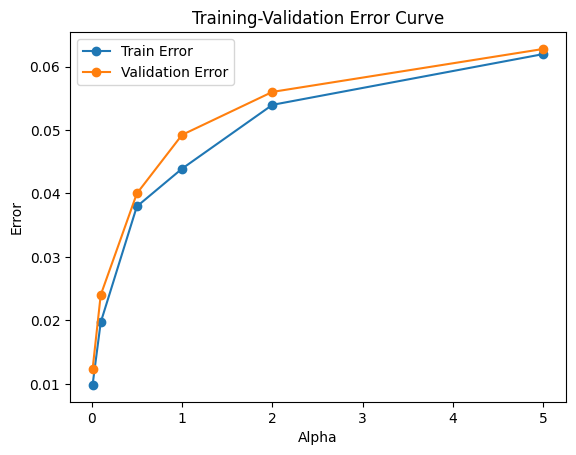

In [28]:
train_errors = [1 - acc for acc in train_accs]
val_errors = [1 - acc for acc in val_accs]

plt.plot(alphas, train_errors, marker='o', label='Train Error')
plt.plot(alphas, val_errors, marker='o', label='Validation Error')

plt.xlabel('Alpha')
plt.ylabel('Error')
plt.title('Training-Validation Error Curve')
plt.legend()
plt.show()

In [31]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

y_test_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("F1 Score:", f1_score(y_test, y_test_pred))

print("\nDetailed Report:\n")
print(classification_report(y_test, y_test_pred))

Accuracy: 0.936
F1 Score: 0.9298245614035088

Detailed Report:

              precision    recall  f1-score   support

           0       0.90      0.99      0.94       843
           1       0.98      0.88      0.93       782

    accuracy                           0.94      1625
   macro avg       0.94      0.93      0.94      1625
weighted avg       0.94      0.94      0.94      1625



In [32]:
cm = confusion_matrix(y_test, y_test_pred)
cm_df = pd.DataFrame(cm,
                     index=["Actual 0 (Edible)", "Actual 1 (Poisonous)"],
                     columns=["Pred 0 (Edible)", "Pred 1 (Poisonous)"])

print(cm_df)

                      Pred 0 (Edible)  Pred 1 (Poisonous)
Actual 0 (Edible)                 832                  11
Actual 1 (Poisonous)               93                 689
